# aggfly quickstart — a standalone, self-contained example

This notebook runs a complete `aggfly` pipeline **entirely on public data downloaded at runtime**.
There are no local data files to obtain, and no accounts, API keys, or authentication of any kind.

It aggregates daily climate-model temperature onto a country boundary, first by **area** and then by
**population**, and shows how the two answers differ.

| Input | Source | Size |
|---|---|---|
| Region boundary | [Natural Earth](https://www.naturalearthdata.com/) 110m countries | ~200 KB |
| Climate data | [CMIP6](https://pangeo-data.github.io/pangeo-cmip6-cloud/) GFDL-CM4 daily `tas`, public Google Cloud Storage | ~20 MB |
| Population | [WorldPop](https://www.worldpop.org/) 1 km population count | ~3 MB |

Total download is roughly **25 MB** and the whole notebook runs in well under a minute.

> **Why CMIP6 rather than ERA5?** ERA5 in the cloud (ARCO-ERA5) is stored as one *full global field*
> per hour, so aggregating a single country still downloads the whole globe — about 3 GB per month.
> The CMIP6 store used here is coarse (1° × 1.25°), so a full year is only ~20 MB. As a bonus it
> exercises two things aggfly handles for you: a **non-standard `noleap` calendar** and
> **0–360 longitudes**.

## 0. Setup

`gcsfs` is needed to read the public Google Cloud Storage bucket. It is not an aggfly dependency,
so install it alongside the package.

In [1]:
# !pip install aggfly gcsfs

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pathlib, urllib.request

import numpy as np
import geopandas as gpd
import aggfly as af

WORKDIR = pathlib.Path('aggfly_example_data')
WORKDIR.mkdir(exist_ok=True)
print('working directory:', WORKDIR.resolve())

working directory: /home/dhogan/repositories/aggfly/examples/notebooks/aggfly_example_data


## 1. The target region

aggfly aggregates onto regions defined by a shapefile. We download Natural Earth's country
boundaries — `geopandas` reads the zipped shapefile straight from the URL — and keep a single
country.

We use **Kenya**: it is compact, has no overseas territories to complicate the geometry, and has a
strong internal population gradient (dense highlands, sparse arid north). That gradient is what makes
population weighting visibly different from area weighting later on.

Change `COUNTRY` to any name in the Natural Earth `NAME` column to re-run the whole notebook elsewhere.

In [2]:
COUNTRY = 'Kenya'
NE_URL = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'

world = gpd.read_file(NE_URL)
region = world[world.NAME == COUNTRY][['NAME', 'ISO_A3', 'geometry']].copy()

shp_path = WORKDIR / 'region.shp'
region.to_file(shp_path)

print(f'{COUNTRY}: bounds =', np.round(region.total_bounds, 2))
region

Kenya: bounds = [33.89 -4.68 41.86  5.51]


,NAME,ISO_A3,geometry
13,Kenya,KEN,"POLYGON ((39.20222 -4.67677, 37.7669 -3.67712,..."


`georegions_from_path` wraps the shapefile. `regionid` names the column holding the region
identifier — it becomes the key of the output panel.

<Axes: >

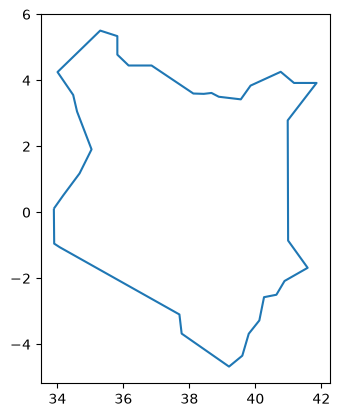

In [3]:
georegions = af.georegions_from_path(str(shp_path), regionid='ISO_A3')
georegions.plot_region('KEN')

## 2. The climate data

We open one year of daily near-surface air temperature (`tas`) from a CMIP6 model, straight from
public cloud storage.

Three arguments deserve attention:

- **`engine='zarr'`** — aggfly infers the reader from the file extension, and this store's path has no
  `.zarr` suffix, so we name the backend explicitly.
- **`storage_options={'token': 'anon'}`** — anonymous read access; passed through to xarray.
- **`preprocess=lambda x: x - 273.15`** — the raw data is in Kelvin; this converts to Celsius before
  any aggregation happens.

Passing `georegions` lets aggfly clip the raster to the region's extent as it reads — a pure
optimization that never changes results.

In [4]:
CMIP6_URL = ('gs://cmip6/CMIP6/CMIP/NOAA-GFDL/GFDL-CM4/'
             'historical/r1i1p1f1/day/tas/gr1/v20180701/')
YEAR = 2010

dataset = af.dataset_from_path(
    CMIP6_URL,
    var='tas',
    xycoords=('lon', 'lat'),          # this store names its coords lon/lat
    timecoord='time',
    time_sel=slice(f'{YEAR}-01-01', f'{YEAR}-12-31'),
    georegions=georegions,            # clip to the region extent while reading
    lon_is_360=True,                  # longitudes run 0-360, not -180-180
    preprocess=lambda x: x - 273.15,  # Kelvin -> Celsius
    chunks={'time': 365},
    engine='zarr',
    storage_options={'token': 'anon'},
)

dataset

<xarray.DataArray 'tas' (latitude: 11, longitude: 7, time: 365)> Size: 112kB
dask.array<getitem, shape=(11, 7, 365), dtype=float32, chunksize=(11, 7, 365), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 88B -4.5 -3.5 -2.5 -1.5 ... 2.5 3.5 4.5 5.5
  * longitude  (longitude) float64 56B 34.38 35.62 36.88 38.12 39.38 40.62 41.88
  * time       (time) object 3kB 2010-01-01 12:00:00 ... 2010-12-31 12:00:00
    height     float64 8B ...
Attributes:
    cell_measures:  area: areacella
    cell_methods:   area: time: mean
    interp_method:  conserve_order2
    long_name:      Near-Surface Air Temperature
    original_name:  tas
    standard_name:  air_temperature
    units:          K

Note the calendar. CMIP6 models often use non-standard CF calendars that cannot be represented as
NumPy `datetime64`, so xarray loads them as `cftime` objects. aggfly groups these correctly and
**preserves the model calendar** in the output — no silent conversion to a real-world calendar.

In [5]:
print('calendar type :', type(dataset.da.time.values[0]).__name__)
print('first timestamp:', dataset.da.time.values[0])
print('grid cells     :', dataset.da.sizes)

calendar type : DatetimeNoLeap
first timestamp: 2010-01-01 12:00:00
grid cells     : Frozen({'latitude': 11, 'longitude': 7, 'time': 365})


> **Tip:** the CLI command `aggfly info <path>` reports exactly these fields — coordinate names,
> longitude convention, calendar, time span — for any dataset, so you don't have to guess them.

## 3. Area weights

Spatial aggregation is a *weighted* average of grid cells over the region. Area weights account for
two things at once:

1. **How much of each cell falls inside the region** — border cells count proportionally.
2. **Latitude distortion** — a 1° cell covers far less ground near the poles than at the equator, so
   cell areas get a cosine-of-latitude correction.

Weights depend only on the grid and the regions, never on the data values, so they are computed once
and reused for every year. Setting `project_dir` caches them on disk.

In [6]:
weights_area = af.weights_from_objects(
    dataset,
    georegions,
    project_dir=str(WORKDIR / 'proj'),
)
weights_area.calculate_weights()

print('weighted cells:', len(weights_area.weights))
weights_area.weights.head()

aggfly_example_data/proj/tmp/GridWeights/mod-8d2bf23ff04cb31
Loading rescaled weights from cache
Cache dictionary:
{'func': 'weights', 'raster_weights': None}
weighted cells: 55


,ISO_A3,cell_id,index_right,area_weight,longitude,latitude,weight
0,KEN,24,0,0.999657,38.125,-1.5,0.999657
1,KEN,25,0,0.999657,39.375,-1.5,0.999657
2,KEN,30,0,0.999962,36.875,-0.5,0.999962
3,KEN,31,0,0.999962,38.125,-0.5,0.999962
4,KEN,32,0,0.999962,39.375,-0.5,0.999962


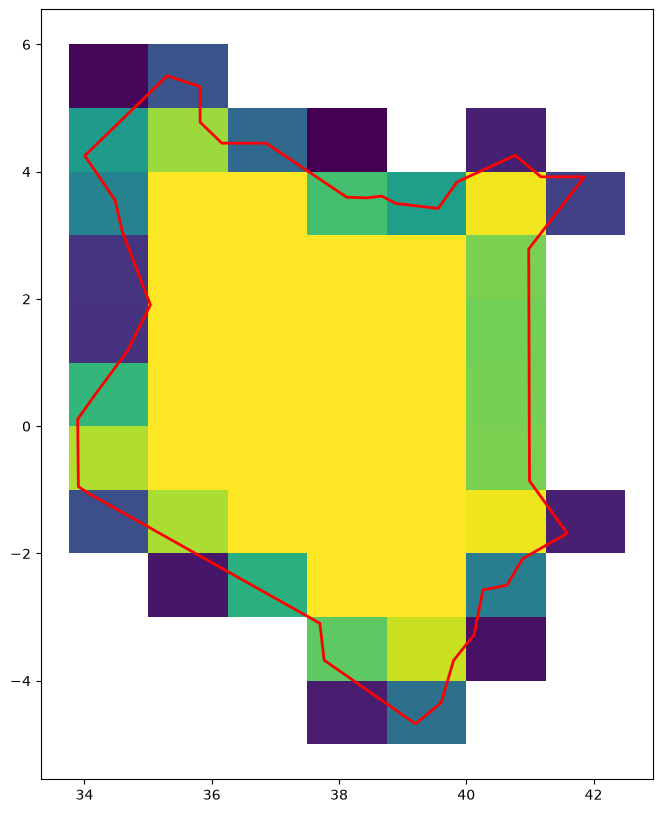

In [7]:
weights_area.plot_weights(region='KEN')

## 4. Aggregate

`aggregate_dataset` runs **temporal aggregation first, then spatial**. That order matters: quantities
like degree days are *nonlinear* in temperature, so averaging over space first and transforming
afterwards would give a different — and wrong — answer.

Each keyword argument names an output variable and maps to a list of steps applied in order:

- `tavg` — average each cell's daily values over the year.
- `gdd` — growing degree days: accumulate degrees between 10 °C and 30 °C each day, then sum the year.
- `hot_days` — count days in temperature bins (above 25 °C, above 30 °C).

In [8]:
panel_area = af.aggregate_dataset(
    dataset=dataset,
    weights=weights_area,
    tavg=[
        ('aggregate', {'calc': 'mean', 'groupby': 'year'}),
    ],
    gdd=[
        ('aggregate', {'calc': 'dd',  'groupby': 'date', 'ddargs': [10, 30, 0]}),
        ('aggregate', {'calc': 'sum', 'groupby': 'year'}),
    ],
    hot_days=[
        ('aggregate', {'calc': 'mean', 'groupby': 'date'}),
        ('aggregate', {'calc': 'bins', 'groupby': 'year',
                       'ddargs': [[25, 99, 0], [30, 99, 0]]}),
    ],
)

panel_area

[########################################] | 100% Completed | 2.99 ss


,ISO_A3,time,tavg,gdd,hot_days_25_99,hot_days_30_99
0,KEN,2010-12-31 00:00:00,24.796575,4619.922793,189.392718,36.990032


## 5. Population weights

Area weighting answers *"what was the average temperature over this land area?"* Often the more
useful question is *"what temperature did the average **person** experience?"* — for which we weight
cells by population.

We download a 1 km WorldPop population-count raster. Unlike the climate store, this must be a local
file: the underlying reader (rasterio) cannot open it straight from an `https://` URL.

In [9]:
POP_URL = (f'https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/'
           f'2020/KEN/ken_ppp_2020_1km_Aggregated.tif')
pop_path = WORKDIR / 'population.tif'

if not pop_path.exists():
    urllib.request.urlretrieve(POP_URL, pop_path)

print(f'population raster: {pop_path.stat().st_size / 1e6:.1f} MB')

population raster: 3.3 MB


Load it as a secondary weight and rebuild the weights. The final weight is the **product** of the
area weight and the population weight — aggfly rescales the 1 km population raster onto the coarser
climate grid for you.

In [10]:
secondary = af.pop_weights_from_path(str(pop_path))

weights_pop = af.weights_from_objects(
    dataset,
    georegions,
    secondary_weights=secondary,
    project_dir=str(WORKDIR / 'proj'),
)
weights_pop.calculate_weights()

weights_pop.weights[['ISO_A3', 'cell_id', 'area_weight', 'raster_weight', 'weight']].head()


aggfly_example_data/proj/tmp/GridWeights/mod-da7d7f1cad38b81
Creating new cache (mod-da7d7f1cad38b81) in aggfly_example_data/proj/tmp/GridWeights/mod-da7d7f1cad38b81
Rescaling pop weights to grid.
This might take a few minutes and use a lot of memory...
[                                        ] | 0% Completed | 90.65 us

[########################################] | 100% Completed | 100.65 ms
Cache file aggfly_example_data/proj/tmp/GridWeights/mod-da7d7f1cad38b81/16b1e70d845850f.feather not found.
{'func': 'weights',
 'raster_weights': {'name': None,
                    'path': 'aggfly_example_data/population.tif',
                    'raster': '<xarray.DataArray (latitude: 11, longitude: 7)> '
                              'Size: 308B\n'
                              'array([[        nan,         nan,         '
                              'nan,   2.1790211, 260.27917  ,\n'
                              '                nan,         nan],\n'
                              '       [        nan,         nan,         nan,  '
                              '30.099495 ,  91.07728  ,\n'
                              '        464.82422  ,         nan],\n'
                              '       [        nan,  15.695604 ,  21.853392 ,  '
                              '31.225937 ,   1.6337647,\n'
                 

,ISO_A3,cell_id,area_weight,raster_weight,weight
0,KEN,24,1.0,77.105133,0.016177
1,KEN,25,1.0,3.491417,0.000733
2,KEN,30,1.0,236.902451,0.049703
3,KEN,31,1.0,90.364838,0.018959
4,KEN,32,1.0,28.126350,0.005901


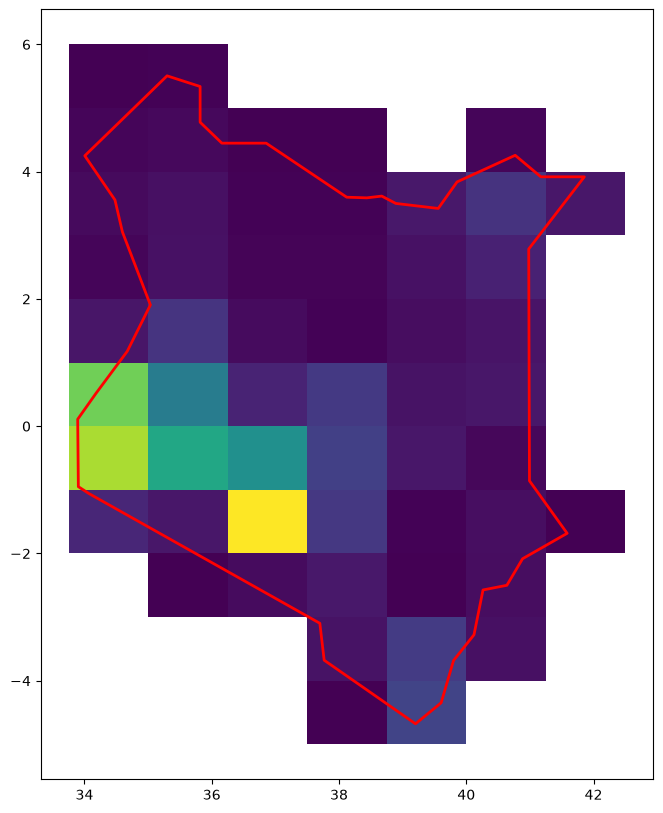

In [16]:
weights_pop.plot_weights(region='KEN')

Notice how `weight` diverges from `area_weight`: cells covering empty land get pushed toward zero,
while densely populated cells dominate. Now aggregate again with these weights.

In [18]:
panel_pop = af.aggregate_dataset(
    dataset=dataset,
    weights=weights_pop,
    tavg=[
        ('aggregate', {'calc': 'mean', 'groupby': 'year'}),
    ],
    gdd=[
        ('aggregate', {'calc': 'dd',  'groupby': 'date', 'ddargs': [10, 30, 0]}),
        ('aggregate', {'calc': 'sum', 'groupby': 'year'}),
    ],
)

panel_pop

[########################################] | 100% Completed | 2.61 ss


,ISO_A3,time,tavg,gdd
0,KEN,2010-12-31 00:00:00,21.393519,3967.631672


### Area vs population weighting

The comparison is the point of the exercise — same data, same period, same region; only the weights
differ.

In [19]:
comparison = (
    panel_area[['ISO_A3', 'tavg', 'gdd']]
    .merge(panel_pop[['ISO_A3', 'tavg', 'gdd']],
           on='ISO_A3', suffixes=('_area', '_pop'))
)
comparison['tavg_diff'] = comparison['tavg_pop'] - comparison['tavg_area']
comparison['gdd_diff']  = comparison['gdd_pop']  - comparison['gdd_area']
comparison

,ISO_A3,tavg_area,gdd_area,tavg_pop,gdd_pop,tavg_diff,gdd_diff
0,KEN,24.796575,4619.922793,21.393519,3967.631672,-3.403057,-652.291121


For Kenya the population-weighted temperature comes out **cooler** than the area-weighted one.
That is the expected result and a good sanity check: most Kenyans live in the temperate central
highlands, while much of the country's *area* is hot, sparsely inhabited lowland. Weighting by
people rather than by hectares therefore shifts the average downward.

Which weighting is 'right' depends entirely on your research question — that is exactly why aggfly
makes it an explicit choice.

## 6. The same run from the command line

Everything above can also be expressed as a YAML config and run with `aggfly run`, no Python required.

The CLI reads local paths, so we first materialize the small regional cutout to a local Zarr store.
This is a useful pattern in its own right: **download the region once, then aggregate from the cheap
local copy as many times as you like.**

In [20]:
import xarray as xr

zarr_path = WORKDIR / 'climate.zarr'

raw = xr.open_dataset(CMIP6_URL, engine='zarr', chunks={'time': 365},
                      storage_options={'token': 'anon'})

# Pad the bounding box so the cutout keeps every cell that *touches* the region.
# Slicing to the exact bounds would drop partially-overlapping edge cells and
# change the weighted average.
PAD = 2.0
lon_lo, lat_lo, lon_hi, lat_hi = region.total_bounds

cutout = raw[['tas']].sel(
    time=slice(f'{YEAR}-01-01', f'{YEAR}-12-31'),
    lat=slice(lat_lo - PAD, lat_hi + PAD),
    lon=slice(lon_lo - PAD, lon_hi + PAD),
).chunk({'time': 365, 'lat': -1, 'lon': -1})

for v in list(cutout.variables):   # drop inherited zarr-v2 codecs
    cutout[v].encoding.clear()

cutout.to_zarr(zarr_path, mode='w', consolidated=True)
print('local cutout written:', dict(cutout.sizes))

[########################################] | 100% Completed | 1.71 ss
local cutout written: {'time': 365, 'lat': 15, 'lon': 9}


Now the config. Note `preprocess: kelvin_to_celsius` — a named builtin, so the unit conversion needs
no code. The `variables` block is the same step DSL used above, written as YAML lists.

In [21]:
config = f'''
regions:
  path: region.shp
  regionid: ISO_A3

dataset:
  path: climate.zarr
  var: tas
  xycoords: [lon, lat]
  timecoord: time
  lon_is_360: true
  preprocess: kelvin_to_celsius
  chunks: {{time: 365, lat: -1, lon: -1}}

weights:
  project_dir: ./proj

aggregate:
  variables:
    tavg:
      - [aggregate, {{calc: mean, groupby: year}}]
    gdd:
      - [aggregate, {{calc: dd, groupby: date, ddargs: [10, 30, 0]}}]
      - [aggregate, {{calc: sum, groupby: year}}]

output:
  path: panel.csv
'''

(WORKDIR / 'config.yaml').write_text(config)
print(config)


regions:
  path: region.shp
  regionid: ISO_A3

dataset:
  path: climate.zarr
  var: tas
  xycoords: [lon, lat]
  timecoord: time
  lon_is_360: true
  preprocess: kelvin_to_celsius
  chunks: {time: 365, lat: -1, lon: -1}

weights:
  project_dir: ./proj

aggregate:
  variables:
    tavg:
      - [aggregate, {calc: mean, groupby: year}]
    gdd:
      - [aggregate, {calc: dd, groupby: date, ddargs: [10, 30, 0]}]
      - [aggregate, {calc: sum, groupby: year}]

output:
  path: panel.csv



`aggfly validate` checks the config statically — it reads no data, and prints a normalized plan.
This is the fastest way to catch a typo before starting a long job.

In [22]:
!cd aggfly_example_data && aggfly validate config.yaml

I0721 15:16:54.436562 1348725 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


Normalized plan
  regions   : region.shp  (id column: ISO_A3)
  dataset   : climate.zarr  var=tas
              lon_is_360=True timecoord=time xycoords=['lon', 'lat']
              preprocess: kelvin_to_celsius
  weights   : area-only
  engine    : auto   backend: threads
  output    : panel.csv  (csv)
  variables : 2
    - tavg: aggregate:mean@year
    - gdd: aggregate:dd@date -> aggregate:sum@year

Config OK.


Then run it for real:

In [23]:
!cd aggfly_example_data && aggfly run config.yaml

I0721 15:16:57.695458 1348725 fork_posix.cc:71] Other threads are currently calling into gRPC, skipping fork() handlers


./proj/tmp/GridWeights/mod-0a3e39847dc7332
Creating new cache (mod-0a3e39847dc7332) in ./proj/tmp/GridWeights/mod-0a3e39847dc7332
Cache file ./proj/tmp/GridWeights/mod-0a3e39847dc7332/c2d709b1733d84f.feather not found.
{'func': 'weights', 'raster_weights': None}
Searching for border cells...
Negative buffer
Positive buffer
Generating cells...
Intersecting...
Calculating area weight
/home/dhogan/repositories/aggfly/.venv/lib/python3.12/site-packages/pandas/io/feather_format.py:77: FutureWarning: pyarrow.feather.write_feather is deprecated as of 24.0.0. Use pyarrow.ipc.new_file() / RecordBatchFileWriter instead. Feather V2 is the Arrow IPC file format.
  feather.write_feather(df, handles.handle, **kwargs)
[########################################] | 100% Completed | 842.33 ms
Wrote 1 rows to panel.csv (csv).


In [24]:
import pandas as pd

cli_panel = pd.read_csv(WORKDIR / 'panel.csv')
cli_panel

,ISO_A3,time,tavg,gdd
0,KEN,2010-12-31 00:00:00,24.796575,4619.922793


The CLI output matches the Python API result exactly — same pipeline, two front ends.

In [25]:
print('Python API :', panel_area['tavg'].iloc[0])
print('CLI        :', cli_panel['tavg'].iloc[0])
print('identical  :', np.allclose(panel_area['tavg'].iloc[0], cli_panel['tavg'].iloc[0]))

Python API : 24.796575215515112
CLI        : 24.796575215515112
identical  : True


## Where to go next

- **[Concepts](../../docs/concepts.md)** — how the pipeline fits together and why weighting matters.
- **[Aggregation](../../docs/guide/aggregation.md)** — the full step DSL: every `calc`, transforms,
  polynomials, bins.
- **[Weights](../../docs/guide/weights.md)** — area, population and cropland weighting.
- **[Execution & scaling](../../docs/guide/execution.md)** — Dask backends for large jobs; the same
  code scales from a laptop to an HPC cluster.
- **[Calendars](../../docs/guide/calendars.md)** — more on CMIP6 and non-standard calendars.
- **[CLI reference](../../docs/cli.md)** — the full config schema.

### Scaling this up

This example deliberately stays small. Real work differs in two ways:

1. **More regions.** Swap the single country for a full administrative shapefile (e.g. all US
   counties) — nothing else changes; the panel simply gains rows.
2. **Finer, larger data.** For ERA5-resolution inputs over many years, read from a local or
   regionally-chunked store and start a Dask client first
   (`af.start_dask_client(n_workers=16, threads_per_worker=1)`). Results are identical across
   backends — only the speed changes.